In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project root - going up one level from notebooks/ give us the repo root
PROJECT_ROOT = Path.cwd().parent
RAW_DATA = PROJECT_ROOT / "data" / "raw" / "2026-04-21_elist_data_cleaned.xlsx"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data file: {RAW_DATA}")
print(f"File exists: {RAW_DATA.exists()}")
print(f"File size: {RAW_DATA.stat().st_size / 1024 / 1024:.1f} MB")

con = duckdb.connect(":memory:")
print(f"\nDuckDB version: {duckdb.__version__}")

Project root: C:\data-projects\cohort-retention
Raw data file: C:\data-projects\cohort-retention\data\raw\2026-04-21_elist_data_cleaned.xlsx
File exists: True
File size: 18.0 MB

DuckDB version: 1.5.2


In [2]:
# Read both sheets from the Excel file into pandas
df_orders = pd.read_excel(RAW_DATA, sheet_name="orders_data_cleaned")
df_lookup = pd.read_excel(RAW_DATA, sheet_name="country_lookup_raw")

# Register the DataFrames as DuckDB tables (zero-copy: just a pointer(Index), not a duplicate)
con.register("orders_raw", df_orders)
con.register("country_lookup_raw", df_lookup)

# Confirm shapes
print(f"orders_raw:         {len(df_orders):>7,} rows × {len(df_orders.columns)} columns")
print(f"country_lookup_raw: {len(df_lookup):>7,} rows × {len(df_lookup.columns)} columns")

orders_raw:         108,127 rows × 26 columns
country_lookup_raw:     193 rows × 2 columns


In [3]:
# Ask DuckDB to describe the structure of the orders_raw table
con.sql("DESCRIBE orders_raw").show()

┌─────────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│           column_name           │ column_type │  null   │   key   │ default │  extra  │
│             varchar             │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ USER_ID                         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ORDER_ID                        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ PURCHASE_TS                     │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ PURCHASE_TS_cleaned             │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ SHIP_TS                         │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ DELIVERY_TS                     │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ REFUND_TS                       │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ REFUND_T

In [4]:
# Show 5 sample rows from orders_raw
con.sql("SELECT * FROM orders_raw LIMIT 5").df()

,USER_ID,ORDER_ID,PURCHASE_TS,PURCHASE_TS_cleaned,SHIP_TS,DELIVERY_TS,REFUND_TS,REFUND_TS_cleaned,REFUND_TS_sanity check,PRODUCT_NAME,...,CURRENCY,PURCHASE_PLATFORM,MARKETING_CHANNEL,MARKETING_CHANNEL_cleaned,ACCOUNT_CREATION_METHOD,ACCOUNT_CREATION_METHOD_cleaned,COUNTRY_CODE,COUNTRY_CODE_cleaned,LOYALTY_PROGRAM,CREATED_ON
0,24560,5f87a27686c1,2021-04-20,2021-04-20,2021-04-23,2021-04-26,NaT,NaT,None,27in 4K gaming monitor,...,JPY,website,email,None,mobile,NaN,JP,JP,1,2021-02-25
1,62488,5c404f671902,2022-05-27,2022-05-27,2022-05-29,2022-06-06,NaT,NaT,None,Samsung Charging Cable Pack,...,USD,website,direct,None,desktop,NaN,US,US,0,2022-02-20
2,74155,424e94e485f3,2022-12-14,2022-12-14,2022-12-15,2022-12-19,NaT,NaT,None,Apple Airpods Headphones,...,EUR,website,direct,None,desktop,NaN,IT,IT,0,2019-07-13
3,122725,6ebc18196ce4,2019-01-31,2019-01-31,2019-02-02,2019-02-07,NaT,NaT,None,Samsung Charging Cable Pack,...,USD,mobile app,email,None,mobile,NaN,US,US,0,2019-01-22
4,134439,1cea3298ca35,2021-03-14,2021-03-14,2021-03-17,2021-03-23,NaT,NaT,None,Apple Airpods Headphones,...,USD,website,direct,None,desktop,NaN,US,US,1,2021-01-20


In [5]:
# Look at sample rows with only the columns relevant to cohort analysis
con.sql("""
    SELECT
        USER_ID,
        ORDER_ID,
        PURCHASE_TS_cleaned,
        CREATED_ON,
        PRODUCT_NAME,
        COUNTRY_CODE_cleaned,
        PURCHASE_PLATFORM,
        LOYALTY_PROGRAM,
        USD_PRICE_cleaned
    FROM orders_raw
    LIMIT 5
""").df()

,USER_ID,ORDER_ID,PURCHASE_TS_cleaned,CREATED_ON,PRODUCT_NAME,COUNTRY_CODE_cleaned,PURCHASE_PLATFORM,LOYALTY_PROGRAM,USD_PRICE_cleaned
0,24560,5f87a27686c1,2021-04-20,2021-02-25,27in 4K gaming monitor,JP,website,1,434.05
1,62488,5c404f671902,2022-05-27,2022-02-20,Samsung Charging Cable Pack,US,website,0,24.00
2,74155,424e94e485f3,2022-12-14,2019-07-13,Apple Airpods Headphones,IT,website,0,103.13
3,122725,6ebc18196ce4,2019-01-31,2019-01-22,Samsung Charging Cable Pack,US,mobile app,0,24.28
4,134439,1cea3298ca35,2021-03-14,2021-01-20,Apple Airpods Headphones,US,website,1,168.00


In [6]:
# Establish the date range of our data and basic counts
con.sql("""
    SELECT
        MIN(PURCHASE_TS_cleaned) AS earliest_purchase,
        MAX(PURCHASE_TS_cleaned) AS latest_purchase,
        DATE_DIFF('month', MIN(PURCHASE_TS_cleaned), MAX(PURCHASE_TS_cleaned)) AS span_months,
        COUNT(DISTINCT USER_ID) AS unique_users,
        COUNT(*) AS total_orders
    FROM orders_raw
""").df()

,earliest_purchase,latest_purchase,span_months,unique_users,total_orders
0,2019-01-01,2022-12-31,47,87628,108127


In [7]:
# Data quality checks: are there any nulls, duplicates, or impossible dates
# that would silently break our cohort analysis?
con.sql("""
    SELECT
        SUM(CASE WHEN USER_ID IS NULL THEN 1 ELSE 0 END) AS null_user_ids,
        SUM(CASE WHEN PURCHASE_TS_cleaned IS NULL THEN 1 ELSE 0 END) AS null_purchase_dates,
        SUM(CASE WHEN ORDER_ID IS NULL THEN 1 ELSE 0 END) AS null_order_ids,
        COUNT(*) - COUNT(DISTINCT ORDER_ID) AS duplicate_order_ids,
        SUM(CASE WHEN PURCHASE_TS_cleaned > CURRENT_DATE THEN 1 ELSE 0 END) AS future_dated_orders
    FROM orders_raw
""").df()

,null_user_ids,null_purchase_dates,null_order_ids,duplicate_order_ids,future_dated_orders
0,0.0,3.0,0.0,0,0.0


In [8]:
# Look at the 3 orders missing PURCHASE_TS_cleaned to understand what's going on
con.sql("""
    SELECT
        USER_ID,
        ORDER_ID,
        PURCHASE_TS_cleaned,
        CREATED_ON,
        PRODUCT_NAME,
        COUNTRY_CODE_cleaned,
        USD_PRICE_cleaned
    FROM orders_raw
    WHERE PURCHASE_TS_cleaned IS NULL
""").df()

,USER_ID,ORDER_ID,PURCHASE_TS_cleaned,CREATED_ON,PRODUCT_NAME,COUNTRY_CODE_cleaned,USD_PRICE_cleaned
0,a5298a4d,0dda212aaea69940,NaT,2019-07-22,Samsung Charging Cable Pack,FR,21.96
1,a591f271,d591f9703fe70151,NaT,2018-12-26,Apple Airpods Headphones,US,168.00
2,c9b897f0,808df003fb785277,NaT,2020-07-09,Apple Airpods Headphones,US,168.00


In [9]:
con.sql("""
    CREATE OR REPLACE TABLE dim_users AS
    WITH ranked_orders AS (
        SELECT
            USER_ID,
            PURCHASE_TS_cleaned,
            COUNTRY_CODE_cleaned,
            PURCHASE_PLATFORM,
            PRODUCT_NAME,
            LOYALTY_PROGRAM,
            ROW_NUMBER() OVER (
                PARTITION BY USER_ID
                ORDER BY PURCHASE_TS_cleaned ASC
            ) AS order_rank
        FROM orders_raw
        WHERE PURCHASE_TS_cleaned IS NOT NULL
    )
    SELECT
        USER_ID,
        PURCHASE_TS_cleaned                      AS first_purchase_date,
        DATE_TRUNC('month', PURCHASE_TS_cleaned) AS first_purchase_month,
        COUNTRY_CODE_cleaned                     AS first_purchase_country,
        PURCHASE_PLATFORM                        AS first_purchase_platform,
        PRODUCT_NAME                             AS first_purchase_product,
        LOYALTY_PROGRAM                          AS loyalty_at_first_purchase
    FROM ranked_orders
    WHERE order_rank = 1
""")

con.sql("SELECT COUNT(*) AS user_count FROM dim_users").df()

,user_count
0,87625


In [10]:
con.sql("""
    SELECT
        COUNT(*)                                            AS total_rows,
        COUNT(DISTINCT USER_ID)                             AS unique_user_ids,
        COUNT(*) - COUNT(DISTINCT USER_ID)                  AS pk_duplicates,
        SUM(CASE WHEN first_purchase_month IS NULL THEN 1 ELSE 0 END) AS null_cohort_months,
        MIN(first_purchase_month)                           AS earliest_cohort,
        MAX(first_purchase_month)                           AS latest_cohort,
        COUNT(DISTINCT first_purchase_month)                AS distinct_cohorts
    FROM dim_users
""").df()

,total_rows,unique_user_ids,pk_duplicates,null_cohort_months,earliest_cohort,latest_cohort,distinct_cohorts
0,87625,87625,0,0.0,2019-01-01,2022-12-01,48


In [11]:
cohort_sizes = con.sql("""
    SELECT
        first_purchase_month AS cohort_month,
        COUNT(*) AS new_users
    FROM dim_users
    GROUP BY first_purchase_month
    ORDER BY first_purchase_month
""").df()

print(f"Cohorts: {len(cohort_sizes)}")
print(f"Smallest: {cohort_sizes['new_users'].min():,}")
print(f"Largest:  {cohort_sizes['new_users'].max():,}")
print(f"Median:   {int(cohort_sizes['new_users'].median()):,}")
print()
print(cohort_sizes.head(6))
print("...")
print(cohort_sizes.tail(6))

Cohorts: 48
Smallest: 625
Largest:  2,887
Median:   2,035

  cohort_month  new_users
0   2019-01-01       1237
1   2019-02-01       1096
2   2019-03-01       1213
3   2019-04-01       1172
4   2019-05-01       1130
5   2019-06-01       1027
...
   cohort_month  new_users
42   2022-07-01       1651
43   2022-08-01       1330
44   2022-09-01        919
45   2022-10-01        702
46   2022-11-01        651
47   2022-12-01        625


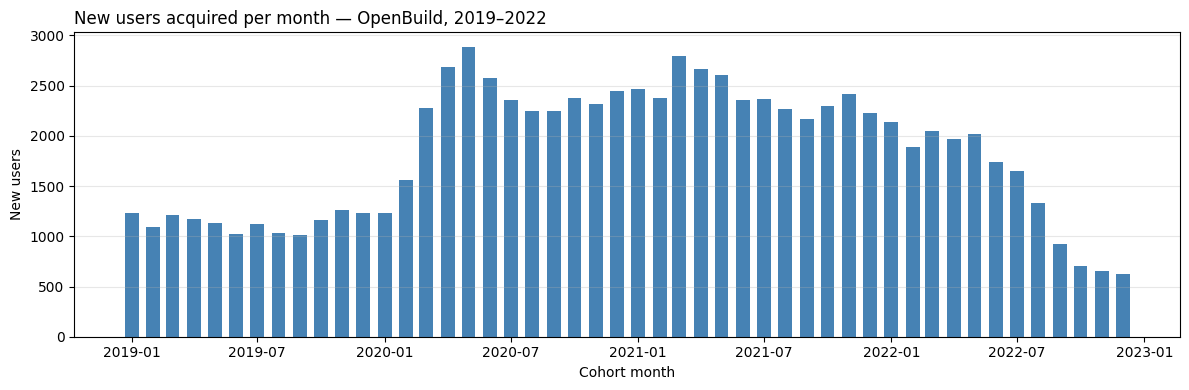

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(cohort_sizes['cohort_month'], cohort_sizes['new_users'],
       width=20, color='steelblue')
ax.set_title('New users acquired per month — OpenBuild, 2019–2022', loc='left')
ax.set_xlabel('Cohort month')
ax.set_ylabel('New users')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
cohort_retention = con.sql("""
    WITH user_orders AS (
        -- For each order, compute months since the user's first purchase
        SELECT
            o.USER_ID,
            u.first_purchase_month AS cohort_month,
            DATE_DIFF('month',
                      u.first_purchase_month,
                      DATE_TRUNC('month', o.PURCHASE_TS_cleaned)
            ) AS months_since_acquisition
        FROM orders_raw o
        INNER JOIN dim_users u USING (USER_ID)
        WHERE o.PURCHASE_TS_cleaned IS NOT NULL
    ),
    cohort_active_users AS (
        -- Count distinct users active in each (cohort, month-offset) cell
        SELECT
            cohort_month,
            months_since_acquisition,
            COUNT(DISTINCT USER_ID) AS active_users
        FROM user_orders
        GROUP BY cohort_month, months_since_acquisition
    ),
    cohort_size AS (
        -- Cohort size = active users at month 0 (everyone is active in their first month by definition)
        SELECT
            cohort_month,
            active_users AS cohort_size
        FROM cohort_active_users
        WHERE months_since_acquisition = 0
    )
    SELECT
        a.cohort_month,
        a.months_since_acquisition,
        a.active_users,
        s.cohort_size,
        ROUND(a.active_users * 100.0 / s.cohort_size, 2) AS retention_pct
    FROM cohort_active_users a
    INNER JOIN cohort_size s USING (cohort_month)
    ORDER BY a.cohort_month, a.months_since_acquisition
""").df()

print(f"Rows in cohort_retention: {len(cohort_retention):,}")
print(cohort_retention.head(10))

Rows in cohort_retention: 1,049
  cohort_month  months_since_acquisition  active_users  cohort_size  \
0   2019-01-01                         0          1237         1237   
1   2019-01-01                         1            13         1237   
2   2019-01-01                         2            10         1237   
3   2019-01-01                         3             9         1237   
4   2019-01-01                         4             4         1237   
5   2019-01-01                         5             5         1237   
6   2019-01-01                         6             1         1237   
7   2019-01-01                         7             2         1237   
8   2019-01-01                         8             3         1237   
9   2019-01-01                         9             4         1237   

   retention_pct  
0         100.00  
1           1.05  
2           0.81  
3           0.73  
4           0.32  
5           0.40  
6           0.08  
7           0.16  
8           0.2

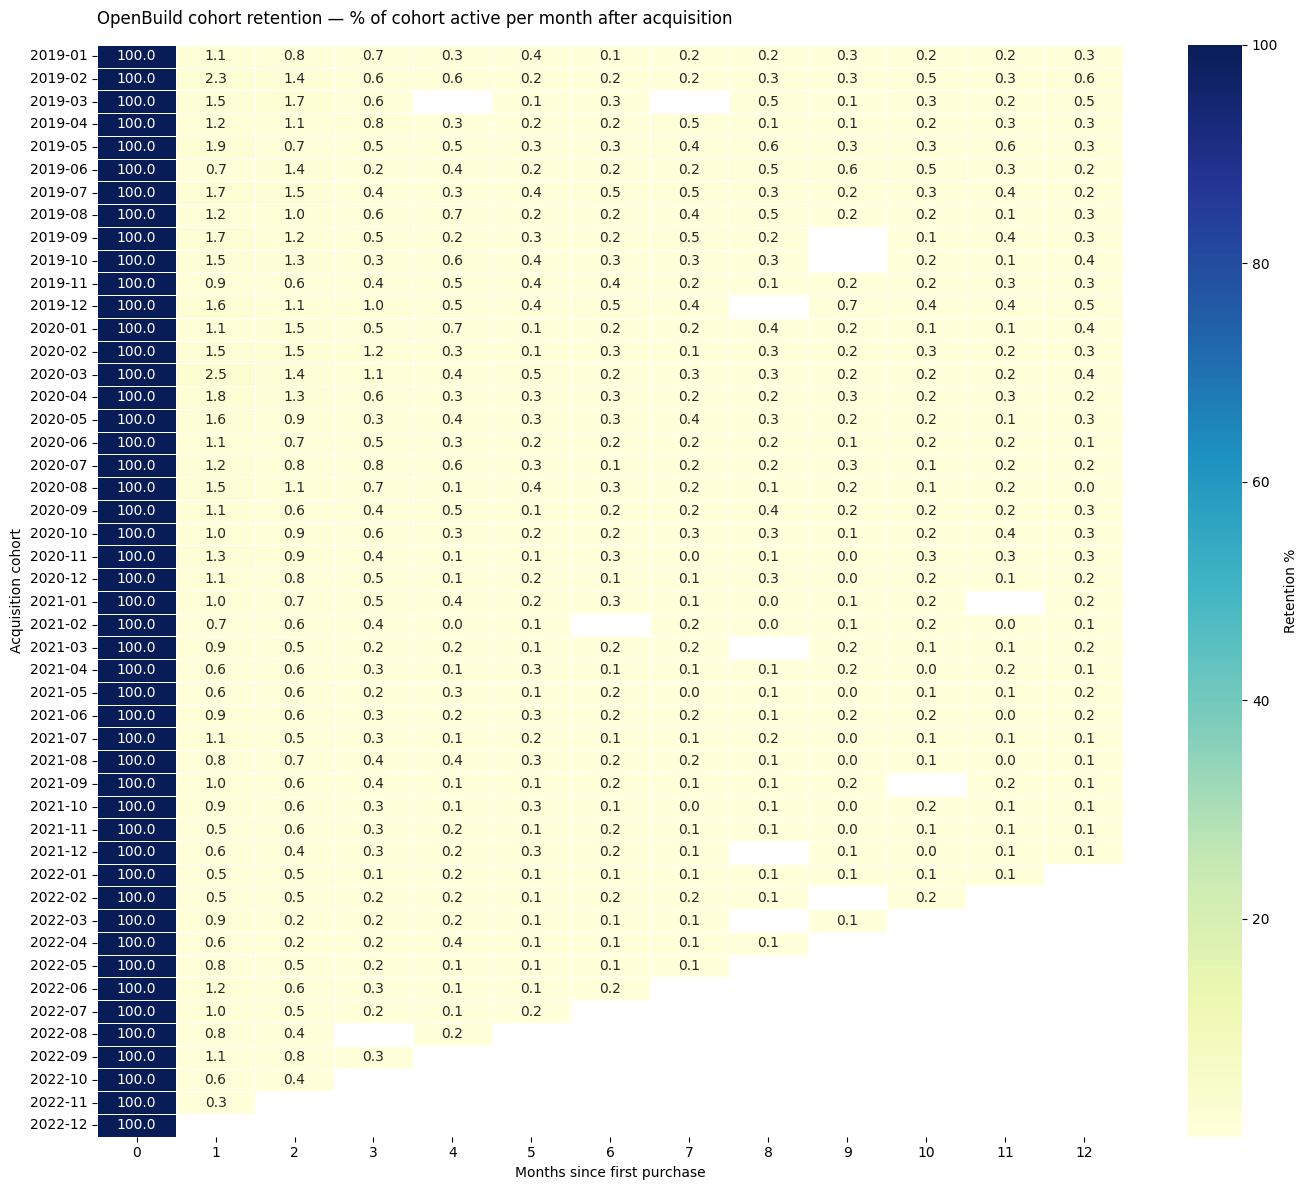

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot long → wide. Rows = cohort, columns = month offset, cells = retention %
retention_matrix = cohort_retention.pivot(
    index='cohort_month',
    columns='months_since_acquisition',
    values='retention_pct'
)

# Format the cohort_month index as 'YYYY-MM' (no timestamp clutter)
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')

# Limit visible columns to months 0–12 to avoid right-censored noise
retention_matrix_12mo = retention_matrix.iloc[:, 0:13]

# Mask the right-censored region (cohorts past Dec 2021 can't be observed at month 12)
# We keep all cells but visually limit the heatmap to months 0–12
retention_matrix_12mo = retention_matrix.iloc[:, 0:13]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    retention_matrix_12mo,
    annot=True, fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention %'},
    ax=ax,
    linewidths=0.5,
    linecolor='white'
)
ax.set_title('OpenBuild cohort retention — % of cohort active per month after acquisition',
             loc='left', pad=15)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Acquisition cohort')
plt.tight_layout()
plt.show()

In [15]:
con.sql("""
CREATE OR REPLACE TABLE stg_orders AS
SELECT
    USER_ID AS user_id,
    ORDER_ID AS order_id,
    PURCHASE_TS_cleaned AS purchase_ts,
    DATE_TRUNC('month', PURCHASE_TS_cleaned) AS purchase_month,
    REFUND_TS_cleaned AS refund_ts,
    SHIP_TS AS ship_ts,
    DELIVERY_TS AS delivery_ts,
    CREATED_ON AS account_created_on,
    PRODUCT_NAME AS product_name,
    PRODUCT_ID AS product_id,
    USD_PRICE_cleaned AS usd_price,
    PURCHASE_PLATFORM AS purchase_platform,
    COUNTRY_CODE_cleaned AS country_code,
    LOYALTY_PROGRAM AS is_loyalty_member,
    CASE WHEN REFUND_TS_cleaned IS NOT NULL THEN 1 ELSE 0 END AS is_refunded
FROM orders_raw
WHERE PURCHASE_TS_cleaned IS NOT NULL
""")

con.sql("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT order_id) AS unique_orders,
    SUM(is_refunded) AS refunded_orders,
    ROUND(100.0 * SUM(is_refunded) / COUNT(*), 2) AS refund_rate_pct
FROM stg_orders
""").df()

,row_count,unique_orders,refunded_orders,refund_rate_pct
0,108124,108124,5379.0,4.97


In [16]:
con.sql("""
CREATE OR REPLACE TABLE dim_users AS
WITH ranked_orders AS (
    SELECT
        user_id,
        purchase_ts,
        purchase_month,
        country_code,
        purchase_platform,
        product_name,
        is_loyalty_member,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY purchase_ts ASC
        ) AS order_rank
    FROM stg_orders
)
SELECT
    user_id,
    purchase_ts                   AS first_purchase_date,
    purchase_month                AS first_purchase_month,
    country_code                  AS first_purchase_country,
    purchase_platform             AS first_purchase_platform,
    product_name                  AS first_purchase_product,
    is_loyalty_member             AS loyalty_at_first_purchase
FROM ranked_orders
WHERE order_rank = 1
""")

con.sql("""
SELECT
    COUNT(*) AS users,
    COUNT(*) - COUNT(DISTINCT user_id) AS pk_duplicates,
    MIN(first_purchase_month) AS earliest_cohort,
    MAX(first_purchase_month) AS latest_cohort
FROM dim_users
""").df()

,users,pk_duplicates,earliest_cohort,latest_cohort
0,87625,0,2019-01-01,2022-12-01


In [17]:
con.sql("""
CREATE OR REPLACE TABLE fct_orders AS
WITH ranked AS (
    SELECT
        o.*,
        u.first_purchase_date,
        u.first_purchase_month AS cohort_month,
        DATE_DIFF('month', u.first_purchase_month, o.purchase_month) AS months_since_acquisition,
        ROW_NUMBER() OVER (
            PARTITION BY o.user_id
            ORDER BY o.purchase_ts ASC, o.order_id ASC
        ) AS user_order_seq
    FROM stg_orders o
    INNER JOIN dim_users u USING (user_id)
)
SELECT
    order_id,
    user_id,
    purchase_ts,
    purchase_month,
    refund_ts,
    is_refunded,
    product_name,
    product_id,
    usd_price,
    purchase_platform,
    country_code,
    is_loyalty_member,
    first_purchase_date,
    cohort_month,
    months_since_acquisition,
    user_order_seq,
    CASE WHEN user_order_seq = 1 THEN 1 ELSE 0 END AS is_first_purchase
FROM ranked
""")

con.sql("""
SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT order_id) AS unique_orders,
    SUM(is_first_purchase) AS first_purchases,
    COUNT(DISTINCT user_id) AS unique_users,
    MIN(months_since_acquisition) AS min_offset,
    MAX(months_since_acquisition) AS max_offset
FROM fct_orders
""").df()

,row_count,unique_orders,first_purchases,unique_users,min_offset,max_offset
0,108124,108124,87625.0,87625,0,47


In [18]:
con.sql("""
SELECT
    user_id,
    purchase_ts,
    COUNT(*) AS orders_same_day
FROM stg_orders
GROUP BY user_id, purchase_ts
HAVING COUNT(*) > 1
ORDER BY orders_same_day DESC
LIMIT 5
""").df()

,user_id,purchase_ts,orders_same_day
0,073cbd94,2022-09-17,3
1,0aa176ad,2020-09-02,3
2,1ad38049,2021-09-07,3
3,0eec4e83,2020-09-15,3
4,276b5f97,2019-12-22,3


In [19]:
con.sql("""
CREATE OR REPLACE TABLE mart_cohort_retention AS
WITH active_users AS (
    SELECT
        cohort_month,
        months_since_acquisition,
        COUNT(DISTINCT user_id) AS active_users
    FROM fct_orders
    GROUP BY cohort_month, months_since_acquisition
),
cohort_size AS (
    SELECT
        cohort_month,
        active_users AS cohort_size
    FROM active_users
    WHERE months_since_acquisition = 0
)
SELECT
    a.cohort_month,
    a.months_since_acquisition,
    a.active_users,
    s.cohort_size,
    ROUND(a.active_users * 100.0 / s.cohort_size, 2) AS retention_pct
FROM active_users a
INNER JOIN cohort_size s USING (cohort_month)
ORDER BY a.cohort_month, a.months_since_acquisition
""")

con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT cohort_month) AS cohorts,
    MIN(retention_pct) AS min_retention,
    MAX(retention_pct) AS max_retention
FROM mart_cohort_retention
""").df()

,rows,cohorts,min_retention,max_retention
0,1049,48,0.03,100.0


In [45]:
tests = [
    # ---- stg_orders ----
    ("stg_orders.order_id is not null",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE order_id IS NULL"),
    ("stg_orders.order_id is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT order_id) AS failures FROM stg_orders"),
    ("stg_orders.user_id is not null",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE user_id IS NULL"),
    ("stg_orders.purchase_ts is not null",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE purchase_ts IS NULL"),
    ("stg_orders.purchase_platform accepted values",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE purchase_platform NOT IN ('website', 'mobile app')"),
    ("stg_orders.is_refunded is 0 or 1",
     "SELECT COUNT(*) AS failures FROM stg_orders WHERE is_refunded NOT IN (0, 1)"),

    # ---- dim_users ----
    ("dim_users.user_id is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT user_id) AS failures FROM dim_users"),
    ("dim_users.first_purchase_month is not null",
     "SELECT COUNT(*) AS failures FROM dim_users WHERE first_purchase_month IS NULL"),
    ("dim_users row count = stg_orders distinct users",
     """SELECT ABS((SELECT COUNT(*) FROM dim_users) -
                   (SELECT COUNT(DISTINCT user_id) FROM stg_orders)) AS failures"""),

    # ---- fct_orders ----
    ("fct_orders.order_id is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT order_id) AS failures FROM fct_orders"),
    ("fct_orders.user_id references dim_users",
     """SELECT COUNT(*) AS failures FROM fct_orders f
        WHERE NOT EXISTS (SELECT 1 FROM dim_users u WHERE u.user_id = f.user_id)"""),
    ("fct_orders.is_first_purchase sums to user count",
     """SELECT ABS(SUM(is_first_purchase) - (SELECT COUNT(*) FROM dim_users)) AS failures
        FROM fct_orders"""),
    ("fct_orders.months_since_acquisition is non-negative",
     "SELECT COUNT(*) AS failures FROM fct_orders WHERE months_since_acquisition < 0"),

    # ---- mart_cohort_retention ----
    ("mart_cohort_retention.month-0 retention is always 100%",
     """SELECT COUNT(*) AS failures FROM mart_cohort_retention
        WHERE months_since_acquisition = 0 AND retention_pct <> 100.00"""),
    ("mart_cohort_retention.retention_pct is between 0 and 100",
     "SELECT COUNT(*) AS failures FROM mart_cohort_retention WHERE retention_pct < 0 OR retention_pct > 100"),
    
    # ---- mart_refund_metrics ----
    ("mart_refund_metrics.product_name is not null",
     "SELECT COUNT(*) AS failures FROM mart_refund_metrics WHERE product_name IS NULL"),
    ("mart_refund_metrics.refund_rate_pct in [0, 100]",
     "SELECT COUNT(*) AS failures FROM mart_refund_metrics WHERE refund_rate_pct < 0 OR refund_rate_pct > 100"),
    ("mart_refund_metrics.refunded + net = gross",
     """SELECT COUNT(*) AS failures FROM mart_refund_metrics
        WHERE ABS(refunded_revenue_usd + net_revenue_usd - gross_revenue_usd) > 0.01"""),

    # ---- mart_channel_revenue ----
    ("mart_channel_revenue.purchase_month is not null",
     "SELECT COUNT(*) AS failures FROM mart_channel_revenue WHERE purchase_month IS NULL"),
    ("mart_channel_revenue.purchase_platform accepted values",
     "SELECT COUNT(*) AS failures FROM mart_channel_revenue WHERE purchase_platform NOT IN ('website', 'mobile app')"),
    ("mart_channel_revenue.share_of_month_pct in [0, 100]",
     "SELECT COUNT(*) AS failures FROM mart_channel_revenue WHERE share_of_month_pct < 0 OR share_of_month_pct > 100"),
    ("mart_channel_revenue.monthly shares sum to 100",
     """SELECT COUNT(*) AS failures FROM (
            SELECT purchase_month, ROUND(SUM(share_of_month_pct), 0) AS month_total
            FROM mart_channel_revenue GROUP BY purchase_month
        ) sub WHERE month_total <> 100"""),

    # ---- referential integrity to new dimensions ----
    ("fct_orders.product_name references dim_product",
     """SELECT COUNT(*) AS failures FROM fct_orders f
        WHERE NOT EXISTS (SELECT 1 FROM dim_product d WHERE d.product_name = f.product_name)"""),
    ("fct_orders.country_code references dim_country",
     """SELECT COUNT(*) AS failures FROM fct_orders f
        WHERE f.country_code IS NOT NULL
          AND NOT EXISTS (SELECT 1 FROM dim_country d WHERE d.country_code = f.country_code)"""),
    ("fct_orders.purchase_platform references dim_platform",
     """SELECT COUNT(*) AS failures FROM fct_orders f
        WHERE NOT EXISTS (SELECT 1 FROM dim_platform d WHERE d.platform_name = f.purchase_platform)"""),

    # ---- new dimension PK uniqueness ----
    ("dim_product.product_name is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT product_name) AS failures FROM dim_product"),
    ("dim_country.country_code is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT country_code) AS failures FROM dim_country"),
    ("dim_platform.platform_name is unique",
     "SELECT COUNT(*) - COUNT(DISTINCT platform_name) AS failures FROM dim_platform"),

]

# Execute all tests
results = []
for name, sql in tests:
    failures = con.sql(sql).df().iloc[0, 0]
    status = "PASS" if failures == 0 else "FAIL"
    results.append({"test": name, "failures": int(failures), "status": status})

results_df = pd.DataFrame(results)
n_pass = (results_df['status'] == 'PASS').sum()
n_fail = (results_df['status'] == 'FAIL').sum()

print(f"{n_pass}/{len(results_df)} tests passed")
if n_fail > 0:
    print(f"⚠️  {n_fail} FAILURES:")
    print(results_df[results_df['status'] == 'FAIL'].to_string(index=False))
else:
    print("✅ All tests pass")

results_df

28/28 tests passed
✅ All tests pass


,test,failures,status
0,stg_orders.order_id is not null,0,PASS
1,stg_orders.order_id is unique,0,PASS
2,stg_orders.user_id is not null,0,PASS
3,stg_orders.purchase_ts is not null,0,PASS
4,stg_orders.purchase_platform accepted values,0,PASS
5,stg_orders.is_refunded is 0 or 1,0,PASS
6,dim_users.user_id is unique,0,PASS
7,dim_users.first_purchase_month is not null,0,PASS
8,dim_users row count = stg_orders distinct users,0,PASS
9,fct_orders.order_id is unique,0,PASS


In [42]:
con.sql("""
SELECT country_code, COUNT(*) AS rows
FROM dim_country
GROUP BY country_code
HAVING COUNT(*) > 1
""").df()

,country_code,rows


In [41]:
con.sql("""
SELECT
    f.country_code,
    COUNT(*) AS orders,
    SUM(f.usd_price) AS revenue_usd
FROM fct_orders f
WHERE f.country_code IS NOT NULL
  AND NOT EXISTS (SELECT 1 FROM dim_country d WHERE d.country_code = f.country_code)
GROUP BY f.country_code
ORDER BY orders DESC
""").df()

,country_code,orders,revenue_usd
0,EU,15,7249.46
1,AP,3,72.00


In [43]:
con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT country_code) AS distinct_codes,
    SUM(CASE WHEN country_code IS NULL THEN 1 ELSE 0 END) AS null_codes
FROM dim_country
""").df()

,total_rows,distinct_codes,null_codes
0,192,191,1.0


In [44]:
# Drop the NULL country_code row, then add EU/AP as Unclassified
con.sql("""
CREATE OR REPLACE TABLE dim_country AS
WITH cleaned AS (
    SELECT country_code, region
    FROM stg_country_lookup
    WHERE country_code IS NOT NULL
)
SELECT * FROM cleaned
UNION ALL
SELECT 'EU', 'Unclassified'
UNION ALL
SELECT 'AP', 'Unclassified'
""")

con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT country_code) AS distinct_codes,
    SUM(CASE WHEN country_code IS NULL THEN 1 ELSE 0 END) AS null_codes
FROM dim_country
""").df()

,total_rows,distinct_codes,null_codes
0,193,193,0.0


In [21]:
con.sql("""
CREATE OR REPLACE TABLE mart_refund_metrics AS
SELECT
    product_name,
    country_code,

    COUNT(*)                                                         AS orders,
    SUM(is_refunded)                                                 AS refunds,
    ROUND(100.0 * SUM(is_refunded) / COUNT(*), 2)                    AS refund_rate_pct,

    ROUND(SUM(usd_price), 2)                                         AS gross_revenue_usd,
    ROUND(SUM(CASE WHEN is_refunded = 1 THEN usd_price ELSE 0 END), 2) AS refunded_revenue_usd,
    ROUND(SUM(CASE WHEN is_refunded = 0 THEN usd_price ELSE 0 END), 2) AS net_revenue_usd,

    ROUND(
        100.0 * SUM(CASE WHEN is_refunded = 1 THEN usd_price ELSE 0 END)
              / NULLIF(SUM(usd_price), 0),
        2
    ) AS refunded_revenue_pct

FROM fct_orders
GROUP BY product_name, country_code
""")

con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT product_name) AS products,
    COUNT(DISTINCT country_code) AS countries,
    MIN(orders) AS min_segment_size,
    MAX(orders) AS max_segment_size
FROM mart_refund_metrics
""").df()

,rows,products,countries,min_segment_size,max_segment_size
0,841,8,193,1,22583


In [22]:
# Angle 1: highest refund rates (statistically reliable segments only)
print("=== HIGHEST REFUND RATES (segments with ≥100 orders) ===")
top_rates = con.sql("""
SELECT
    product_name,
    country_code,
    orders,
    refunds,
    refund_rate_pct,
    refunded_revenue_usd
FROM mart_refund_metrics
WHERE orders >= 100
ORDER BY refund_rate_pct DESC
LIMIT 10
""").df()
print(top_rates.to_string(index=False))

# Angle 2: largest absolute refunded dollars
print("\n=== LARGEST REFUNDED REVENUE (absolute USD) ===")
top_dollars = con.sql("""
SELECT
    product_name,
    country_code,
    orders,
    refunds,
    refund_rate_pct,
    refunded_revenue_usd
FROM mart_refund_metrics
ORDER BY refunded_revenue_usd DESC
LIMIT 10
""").df()
print(top_dollars.to_string(index=False))

=== HIGHEST REFUND RATES (segments with ≥100 orders) ===
      product_name country_code  orders  refunds  refund_rate_pct  refunded_revenue_usd
   ThinkPad Laptop           CA     136     29.0            21.32              28320.73
   ThinkPad Laptop           GB     191     32.0            16.75              38603.22
Macbook Air Laptop           CA     166     27.0            16.27              42474.14
Macbook Air Laptop           GB     164     26.0            15.85              52019.39
   ThinkPad Laptop           AU     131     19.0            14.50              17583.68
   ThinkPad Laptop           US    1236    160.0            12.94             185002.22
Macbook Air Laptop           DE     148     19.0            12.84              32133.39
Macbook Air Laptop           AU     109     14.0            12.84              18383.63
Macbook Air Laptop           BR     120     15.0            12.50              25953.85
Macbook Air Laptop           US    1796    222.0            12.

In [26]:
con.sql("""
CREATE OR REPLACE TABLE mart_channel_revenue AS
WITH monthly AS (
    SELECT
        purchase_month,
        purchase_platform,
        COUNT(*)                                                          AS orders,
        ROUND(SUM(usd_price), 2)                                          AS gross_revenue_usd,
        ROUND(SUM(CASE WHEN is_refunded = 0 THEN usd_price ELSE 0 END), 2) AS net_revenue_usd
    FROM fct_orders
    GROUP BY purchase_month, purchase_platform
),
monthly_total AS (
    SELECT
        purchase_month,
        SUM(net_revenue_usd) AS total_month_net_revenue
    FROM monthly
    GROUP BY purchase_month
)
SELECT
    m.purchase_month,
    m.purchase_platform,
    m.orders,
    m.gross_revenue_usd,
    m.net_revenue_usd,
    ROUND(100.0 * m.net_revenue_usd / NULLIF(t.total_month_net_revenue, 0), 2) AS share_of_month_pct
FROM monthly m
INNER JOIN monthly_total t USING (purchase_month)
ORDER BY m.purchase_month, m.purchase_platform
""")

con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT purchase_month) AS months,
    COUNT(DISTINCT purchase_platform) AS platforms,
    ROUND(SUM(net_revenue_usd), 0) AS total_net_revenue_usd
FROM mart_channel_revenue
""").df()

,rows,months,platforms,total_net_revenue_usd
0,96,48,2,25876396.0


In [28]:
# Lifetime split: website vs mobile app over the full 48-month window
print("=== LIFETIME REVENUE SPLIT ===")
lifetime = con.sql("""
SELECT
    purchase_platform,
    SUM(orders) AS orders,
    ROUND(SUM(net_revenue_usd), 0) AS net_revenue_usd,
    ROUND(100.0 * SUM(net_revenue_usd) / SUM(SUM(net_revenue_usd)) OVER (), 2) AS share_pct
FROM mart_channel_revenue
GROUP BY purchase_platform
ORDER BY net_revenue_usd DESC
""").df()
print(lifetime.to_string(index=False))

# First year vs last year — is the mix shifting?
print("\n=== TREND: FIRST YEAR vs LAST YEAR ===")
trend = con.sql("""
WITH year_buckets AS (
    SELECT
        CASE
            WHEN purchase_month >= '2019-01-01' AND purchase_month <= '2019-12-01' THEN '2019'
            WHEN purchase_month >= '2022-01-01' AND purchase_month <= '2022-12-01' THEN '2022'
        END AS year_bucket,
        purchase_platform,
        net_revenue_usd
    FROM mart_channel_revenue
    WHERE purchase_month BETWEEN '2019-01-01' AND '2019-12-01'
       OR purchase_month BETWEEN '2022-01-01' AND '2022-12-01'
)
SELECT
    year_bucket,
    purchase_platform,
    ROUND(SUM(net_revenue_usd), 0) AS net_revenue_usd,
    ROUND(100.0 * SUM(net_revenue_usd)
          / SUM(SUM(net_revenue_usd)) OVER (PARTITION BY year_bucket), 2) AS share_pct
FROM year_buckets
GROUP BY year_bucket, purchase_platform
ORDER BY year_bucket, purchase_platform
""").df()
print(trend.to_string(index=False))

=== LIFETIME REVENUE SPLIT ===
purchase_platform  orders  net_revenue_usd  share_pct
          website 89607.0       25044205.0      96.78
       mobile app 18517.0         832190.0       3.22

=== TREND: FIRST YEAR vs LAST YEAR ===
year_bucket purchase_platform  net_revenue_usd  share_pct
       2019        mobile app         103237.0       2.95
       2019           website        3394219.0      97.05
       2022        mobile app         194733.0       3.93
       2022           website        4762847.0      96.07


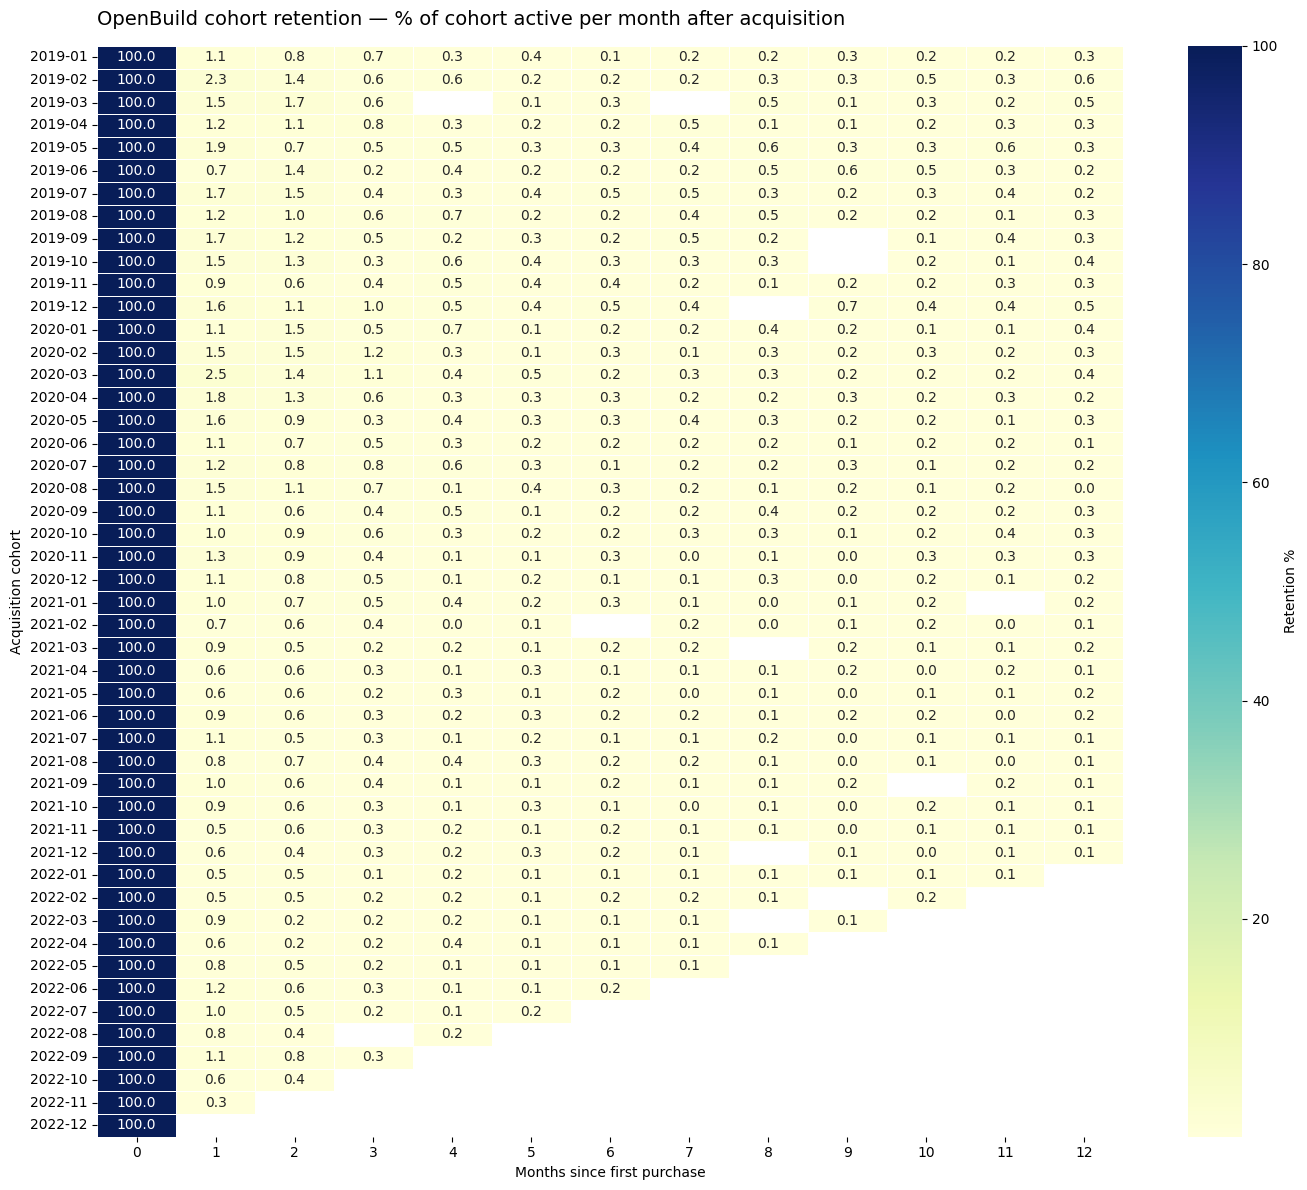


Saved: C:\data-projects\cohort-retention\data\outputs\cohort_retention_heatmap.png
File size: 351.6 KB


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pull from the persisted mart, not the in-memory cohort_retention DataFrame
retention_df = con.sql("SELECT * FROM mart_cohort_retention").df()

# Pivot long → wide
retention_matrix = retention_df.pivot(
    index='cohort_month',
    columns='months_since_acquisition',
    values='retention_pct'
)

# Format cohort_month as YYYY-MM (no timestamp clutter)
retention_matrix.index = retention_matrix.index.strftime('%Y-%m')

# Limit to months 0–12 for readability (right-censored cells beyond)
retention_matrix_12mo = retention_matrix.iloc[:, 0:13]

# Render
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    retention_matrix_12mo,
    annot=True, fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Retention %'},
    ax=ax,
    linewidths=0.5,
    linecolor='white'
)
ax.set_title('OpenBuild cohort retention — % of cohort active per month after acquisition',
             loc='left', pad=15, fontsize=14)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Acquisition cohort')
plt.tight_layout()

# Save to data/outputs/
output_path = PROJECT_ROOT / "data" / "outputs" / "cohort_retention_heatmap.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

In [31]:
architecture_svg = '''<svg xmlns="http://www.w3.org/2000/svg" width="100%" viewBox="0 0 680 620" font-family="Helvetica, Arial, sans-serif">
<defs>
  <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
</defs>

<rect x="20" y="40" width="640" height="100" rx="10" fill="#F1EFE8" stroke="#B4B2A9" stroke-width="0.5"/>
<text x="40" y="68" font-size="14" font-weight="500" fill="#444441">Bronze · raw, immutable</text>

<rect x="80" y="84" width="240" height="44" rx="6" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="0.5"/>
<text x="200" y="100" font-size="14" font-weight="500" fill="#2C2C2A" text-anchor="middle" dominant-baseline="central">orders_raw</text>
<text x="200" y="116" font-size="12" fill="#5F5E5A" text-anchor="middle" dominant-baseline="central">108,127 orders</text>

<rect x="360" y="84" width="240" height="44" rx="6" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="0.5"/>
<text x="480" y="100" font-size="14" font-weight="500" fill="#2C2C2A" text-anchor="middle" dominant-baseline="central">country_lookup_raw</text>
<text x="480" y="116" font-size="12" fill="#5F5E5A" text-anchor="middle" dominant-baseline="central">193 countries</text>

<line x1="200" y1="140" x2="200" y2="178" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="20" y="180" width="640" height="80" rx="10" fill="#F1EFE8" stroke="#B4B2A9" stroke-width="0.5"/>
<text x="40" y="208" font-size="14" font-weight="500" fill="#444441">Silver · staging</text>

<rect x="80" y="216" width="240" height="36" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="200" y="234" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">stg_orders</text>
<text x="340" y="234" font-size="12" fill="#444441" dominant-baseline="central">cleaned, typed, validated</text>

<line x1="200" y1="252" x2="200" y2="296" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<path d="M480 128 L480 316" fill="none" stroke="#888780" stroke-width="0.8" stroke-dasharray="3 3" marker-end="url(#arrow)"/>

<rect x="20" y="298" width="640" height="200" rx="10" fill="#F1EFE8" stroke="#B4B2A9" stroke-width="0.5"/>
<text x="40" y="326" font-size="14" font-weight="500" fill="#444441">Gold · marts</text>

<rect x="80" y="336" width="240" height="44" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="200" y="352" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">dim_users</text>
<text x="200" y="368" font-size="12" fill="#185FA5" text-anchor="middle" dominant-baseline="central">87,625 users</text>

<rect x="360" y="336" width="240" height="44" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="480" y="352" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">fct_orders</text>
<text x="480" y="368" font-size="12" fill="#185FA5" text-anchor="middle" dominant-baseline="central">cohort enriched</text>

<line x1="320" y1="358" x2="356" y2="358" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="420" y1="380" x2="170" y2="428" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="480" y1="380" x2="340" y2="428" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="540" y1="380" x2="540" y2="428" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="60" y="430" width="220" height="48" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="170" y="450" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">mart_cohort_retention</text>
<text x="170" y="466" font-size="12" fill="#185FA5" text-anchor="middle" dominant-baseline="central">cohort × month grain</text>

<rect x="290" y="430" width="220" height="48" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="400" y="450" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">mart_refund_metrics</text>
<text x="400" y="466" font-size="12" fill="#185FA5" text-anchor="middle" dominant-baseline="central">product × country grain</text>

<rect x="520" y="430" width="120" height="48" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="580" y="450" font-size="12" fill="#0C447C" text-anchor="middle" dominant-baseline="central">mart_channel</text>
<text x="580" y="466" font-size="12" fill="#0C447C" text-anchor="middle" dominant-baseline="central">_revenue</text>

<line x1="170" y1="478" x2="170" y2="536" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="400" y1="478" x2="400" y2="536" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="580" y1="478" x2="580" y2="536" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="20" y="538" width="640" height="64" rx="10" fill="#FAEEDA" stroke="#EF9F27" stroke-width="0.5"/>
<text x="40" y="566" font-size="14" font-weight="500" fill="#854F0B">Findings</text>

<rect x="60" y="572" width="220" height="20" rx="4" fill="#FAEEDA" stroke="#BA7517" stroke-width="0.5"/>
<text x="170" y="582" font-size="12" fill="#854F0B" text-anchor="middle" dominant-baseline="central">~1% retention baseline</text>

<rect x="290" y="572" width="220" height="20" rx="4" fill="#FAEEDA" stroke="#BA7517" stroke-width="0.5"/>
<text x="400" y="582" font-size="12" fill="#854F0B" text-anchor="middle" dominant-baseline="central">$365K MBA × US leak</text>

<rect x="520" y="572" width="120" height="20" rx="4" fill="#FAEEDA" stroke="#BA7517" stroke-width="0.5"/>
<text x="580" y="582" font-size="12" fill="#854F0B" text-anchor="middle" dominant-baseline="central">96.8% web</text>
</svg>'''

output_path = PROJECT_ROOT / "data" / "outputs" / "architecture_diagram.svg"
output_path.write_text(architecture_svg, encoding='utf-8')

print(f"Saved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Saved: C:\data-projects\cohort-retention\data\outputs\architecture_diagram.svg
File size: 5.8 KB


In [32]:
star_schema_svg = '''<svg xmlns="http://www.w3.org/2000/svg" width="100%" viewBox="0 0 680 480" font-family="Helvetica, Arial, sans-serif">

<rect x="40" y="60" width="260" height="280" rx="8" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>

<path d="M40 68 Q40 60 48 60 L292 60 Q300 60 300 68 L300 110 L40 110 Z" fill="#185FA5"/>
<text x="60" y="84" font-size="14" font-weight="500" fill="#FFFFFF" dominant-baseline="central">dim_users</text>
<text x="60" y="100" font-size="11" fill="#B5D4F4" dominant-baseline="central">one row per user</text>

<text x="60" y="138" font-size="12" font-weight="500" fill="#0C447C" dominant-baseline="central">user_id</text>
<text x="280" y="138" font-size="12" fill="#0C447C" text-anchor="end" dominant-baseline="central">PK</text>

<text x="60" y="162" font-size="12" fill="#444441" dominant-baseline="central">first_purchase_date</text>
<text x="60" y="186" font-size="12" fill="#444441" dominant-baseline="central">first_purchase_month</text>
<text x="60" y="210" font-size="12" fill="#444441" dominant-baseline="central">first_purchase_country</text>
<text x="60" y="234" font-size="12" fill="#444441" dominant-baseline="central">first_purchase_platform</text>
<text x="60" y="258" font-size="12" fill="#444441" dominant-baseline="central">first_purchase_product</text>
<text x="60" y="282" font-size="12" fill="#444441" dominant-baseline="central">loyalty_at_first_purchase</text>

<text x="60" y="318" font-size="12" font-style="italic" fill="#5F5E5A" dominant-baseline="central">7 columns · 87,625 rows</text>

<line x1="300" y1="200" x2="380" y2="200" stroke="#185FA5" stroke-width="1.5"/>
<circle cx="300" cy="200" r="4" fill="#185FA5"/>
<line x1="372" y1="194" x2="372" y2="206" stroke="#185FA5" stroke-width="1.5"/>
<polyline points="376,194 380,200 376,206" fill="none" stroke="#185FA5" stroke-width="1.5"/>
<text x="340" y="186" font-size="12" fill="#0C447C" text-anchor="middle" dominant-baseline="central">places</text>
<text x="312" y="216" font-size="12" fill="#5F5E5A" text-anchor="middle" dominant-baseline="central">1</text>
<text x="368" y="216" font-size="12" fill="#5F5E5A" text-anchor="middle" dominant-baseline="central">N</text>

<rect x="380" y="60" width="260" height="380" rx="8" fill="#EEEDFE" stroke="#534AB7" stroke-width="0.5"/>

<path d="M380 68 Q380 60 388 60 L632 60 Q640 60 640 68 L640 110 L380 110 Z" fill="#534AB7"/>
<text x="400" y="84" font-size="14" font-weight="500" fill="#FFFFFF" dominant-baseline="central">fct_orders</text>
<text x="400" y="100" font-size="11" fill="#CECBF6" dominant-baseline="central">one row per order</text>

<text x="400" y="138" font-size="12" font-weight="500" fill="#26215C" dominant-baseline="central">order_id</text>
<text x="620" y="138" font-size="12" fill="#26215C" text-anchor="end" dominant-baseline="central">PK</text>

<text x="400" y="162" font-size="12" font-weight="500" fill="#26215C" dominant-baseline="central">user_id</text>
<text x="620" y="162" font-size="12" fill="#26215C" text-anchor="end" dominant-baseline="central">FK</text>

<text x="400" y="186" font-size="12" fill="#444441" dominant-baseline="central">purchase_month</text>
<text x="400" y="210" font-size="12" fill="#444441" dominant-baseline="central">cohort_month</text>
<text x="400" y="234" font-size="12" fill="#444441" dominant-baseline="central">months_since_acquisition</text>
<text x="400" y="258" font-size="12" fill="#444441" dominant-baseline="central">product_name</text>
<text x="400" y="282" font-size="12" fill="#444441" dominant-baseline="central">country_code</text>
<text x="400" y="306" font-size="12" fill="#444441" dominant-baseline="central">purchase_platform</text>
<text x="400" y="330" font-size="12" fill="#444441" dominant-baseline="central">usd_price</text>
<text x="400" y="354" font-size="12" fill="#444441" dominant-baseline="central">is_refunded</text>
<text x="400" y="378" font-size="12" fill="#444441" dominant-baseline="central">is_first_purchase</text>
<text x="400" y="402" font-size="12" fill="#444441" dominant-baseline="central">user_order_seq</text>

<text x="400" y="430" font-size="12" font-style="italic" fill="#5F5E5A" dominant-baseline="central">13 columns · 108,124 rows</text>
</svg>'''

output_path = PROJECT_ROOT / "data" / "outputs" / "star_schema.svg"
output_path.write_text(star_schema_svg, encoding='utf-8')

print(f"Saved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Saved: C:\data-projects\cohort-retention\data\outputs\star_schema.svg
File size: 4.2 KB


In [33]:
# First, let's see what country_lookup_raw actually looks like
con.sql("SELECT * FROM country_lookup_raw LIMIT 5").df()

,COUNTRY_CODE,REGION
0,AD,EMEA
1,AE,EMEA
2,AG,NaN
3,AI,NaN
4,AL,EMEA


In [34]:
con.sql("""
SELECT
    REGION,
    COUNT(*) AS country_count
FROM country_lookup_raw
GROUP BY REGION
ORDER BY country_count DESC
""").df()

,REGION,country_count
0,EMEA,99
1,APAC,44
2,NaN,26
3,LATAM,22
4,x,1
5,North America,1


In [35]:
con.sql("""
SELECT
    COUNTRY_CODE,
    REGION
FROM country_lookup_raw
WHERE COUNTRY_CODE IN ('US', 'CA', 'MX', 'BR', 'AR', 'CL')
   OR REGION IN ('x', 'North America')
ORDER BY COUNTRY_CODE
""").df()

,COUNTRY_CODE,REGION
0,AR,LATAM
1,BR,LATAM
2,CA,NaN
3,CL,LATAM
4,MX,LATAM
5,US,x
6,US,North America


In [36]:
# Silver layer: clean the country lookup
con.sql("""
CREATE OR REPLACE TABLE stg_country_lookup AS
WITH deduped AS (
    -- Resolve duplicates by taking the cleanest available region per country
    SELECT
        COUNTRY_CODE AS country_code,
        -- Apply cleaning rules in priority order
        CASE
            WHEN COUNTRY_CODE = 'US' THEN 'AMER'
            WHEN COUNTRY_CODE = 'CA' THEN 'AMER'
            WHEN REGION IN ('x', 'North America') THEN 'AMER'
            WHEN REGION IS NULL THEN 'Unclassified'
            ELSE REGION
        END AS region
    FROM country_lookup_raw
)
SELECT DISTINCT country_code, region
FROM deduped
""")

# Gold layer: dim_country
con.sql("""
CREATE OR REPLACE TABLE dim_country AS
SELECT
    country_code,
    region
FROM stg_country_lookup
""")

# Verify: no duplicates, region distribution
con.sql("""
SELECT
    region,
    COUNT(*) AS country_count
FROM dim_country
GROUP BY region
ORDER BY country_count DESC
""").df()

,region,country_count
0,EMEA,99
1,APAC,44
2,Unclassified,25
3,LATAM,22
4,AMER,2


In [37]:
con.sql("""
CREATE OR REPLACE TABLE dim_product AS
SELECT
    product_name,
    MIN(product_id) AS product_id
FROM stg_orders
GROUP BY product_name
ORDER BY product_name
""")

con.sql("SELECT * FROM dim_product").df()

,product_name,product_id
0,27in 4K gaming monitor,1238
1,Apple Airpods Headphones,03ca
2,Apple iPhone,22ea
3,Macbook Air Laptop,12b1
4,Samsung Charging Cable Pack,16dc
5,Samsung Webcam,0c5a
6,ThinkPad Laptop,04ac
7,bose soundsport headphones,4f26


In [38]:
con.sql("""
CREATE OR REPLACE TABLE dim_platform AS
SELECT DISTINCT
    purchase_platform AS platform_name,
    CASE
        WHEN purchase_platform = 'website' THEN 'web'
        WHEN purchase_platform = 'mobile app' THEN 'mobile'
    END AS platform_type
FROM stg_orders
ORDER BY platform_name
""")

con.sql("SELECT * FROM dim_platform").df()

,platform_name,platform_type
0,mobile app,mobile
1,website,web


In [49]:
star_schema_svg = '''<svg xmlns="http://www.w3.org/2000/svg" width="100%" viewBox="0 0 680 500" font-family="Helvetica, Arial, sans-serif">

<rect x="40" y="40" width="220" height="120" rx="6" fill="#FFFFFF" stroke="#9CA3AF" stroke-width="0.6"/>
<rect x="40" y="40" width="220" height="32" rx="6" fill="#1F2937"/>
<rect x="40" y="60" width="220" height="12" fill="#1F2937"/>
<text x="56" y="60" font-size="13" font-weight="500" fill="#FFFFFF">dim_users</text>
<text x="244" y="60" font-size="10" fill="#9CA3AF" text-anchor="end">87,625 rows</text>
<text x="56" y="92" font-size="11" font-weight="500" fill="#1F2937">user_id</text>
<text x="244" y="92" font-size="10" fill="#6B7280" text-anchor="end">PK</text>
<text x="56" y="112" font-size="10" fill="#6B7280">first_purchase_date · _month · _country</text>
<text x="56" y="128" font-size="10" fill="#6B7280">first_purchase_platform · _product</text>
<text x="56" y="144" font-size="10" fill="#6B7280">loyalty_at_first_purchase</text>

<rect x="40" y="180" width="220" height="80" rx="6" fill="#FFFFFF" stroke="#9CA3AF" stroke-width="0.6"/>
<rect x="40" y="180" width="220" height="32" rx="6" fill="#1F2937"/>
<rect x="40" y="200" width="220" height="12" fill="#1F2937"/>
<text x="56" y="200" font-size="13" font-weight="500" fill="#FFFFFF">dim_product</text>
<text x="244" y="200" font-size="10" fill="#9CA3AF" text-anchor="end">8 rows</text>
<text x="56" y="232" font-size="11" font-weight="500" fill="#1F2937">product_name</text>
<text x="244" y="232" font-size="10" fill="#6B7280" text-anchor="end">PK</text>
<text x="56" y="248" font-size="10" fill="#6B7280">product_id</text>

<rect x="40" y="280" width="220" height="80" rx="6" fill="#FFFFFF" stroke="#9CA3AF" stroke-width="0.6"/>
<rect x="40" y="280" width="220" height="32" rx="6" fill="#1F2937"/>
<rect x="40" y="300" width="220" height="12" fill="#1F2937"/>
<text x="56" y="300" font-size="13" font-weight="500" fill="#FFFFFF">dim_country</text>
<text x="244" y="300" font-size="10" fill="#9CA3AF" text-anchor="end">193 rows</text>
<text x="56" y="332" font-size="11" font-weight="500" fill="#1F2937">country_code</text>
<text x="244" y="332" font-size="10" fill="#6B7280" text-anchor="end">PK</text>
<text x="56" y="348" font-size="10" fill="#6B7280">region</text>

<rect x="40" y="380" width="220" height="80" rx="6" fill="#FFFFFF" stroke="#9CA3AF" stroke-width="0.6"/>
<rect x="40" y="380" width="220" height="32" rx="6" fill="#1F2937"/>
<rect x="40" y="400" width="220" height="12" fill="#1F2937"/>
<text x="56" y="400" font-size="13" font-weight="500" fill="#FFFFFF">dim_platform</text>
<text x="244" y="400" font-size="10" fill="#9CA3AF" text-anchor="end">2 rows</text>
<text x="56" y="432" font-size="11" font-weight="500" fill="#1F2937">platform_name</text>
<text x="244" y="432" font-size="10" fill="#6B7280" text-anchor="end">PK</text>
<text x="56" y="448" font-size="10" fill="#6B7280">platform_type</text>

<rect x="380" y="40" width="260" height="440" rx="6" fill="#FFFFFF" stroke="#1F2937" stroke-width="1"/>
<rect x="380" y="40" width="260" height="32" rx="6" fill="#0F172A"/>
<rect x="380" y="60" width="260" height="12" fill="#0F172A"/>
<text x="396" y="60" font-size="13" font-weight="500" fill="#FFFFFF">fct_orders</text>
<text x="624" y="60" font-size="10" fill="#94A3B8" text-anchor="end">108,124 rows</text>

<text x="396" y="100" font-size="11" font-weight="500" fill="#1F2937">order_id</text>
<text x="624" y="100" font-size="10" fill="#6B7280" text-anchor="end">PK</text>

<text x="396" y="124" font-size="11" font-weight="500" fill="#1F2937">user_id</text>
<text x="624" y="124" font-size="10" fill="#6B7280" text-anchor="end">FK</text>

<text x="396" y="240" font-size="11" font-weight="500" fill="#1F2937">product_name</text>
<text x="624" y="240" font-size="10" fill="#6B7280" text-anchor="end">FK</text>

<text x="396" y="320" font-size="11" font-weight="500" fill="#1F2937">country_code</text>
<text x="624" y="320" font-size="10" fill="#6B7280" text-anchor="end">FK</text>

<text x="396" y="420" font-size="11" font-weight="500" fill="#1F2937">purchase_platform</text>
<text x="624" y="420" font-size="10" fill="#6B7280" text-anchor="end">FK</text>

<line x1="396" y1="440" x2="624" y2="440" stroke="#E5E7EB" stroke-width="0.5"/>
<text x="396" y="458" font-size="9" fill="#6B7280">+ 7 metric columns:</text>
<text x="396" y="472" font-size="9" fill="#6B7280">purchase_month, usd_price, is_refunded, ...</text>

<path d="M 260 100 L 320 100 L 320 124 L 380 124" fill="none" stroke="#475569" stroke-width="0.8"/>
<path d="M 260 220 L 320 220 L 320 240 L 380 240" fill="none" stroke="#475569" stroke-width="0.8"/>
<path d="M 260 320 L 380 320" fill="none" stroke="#475569" stroke-width="0.8"/>
<path d="M 260 420 L 380 420" fill="none" stroke="#475569" stroke-width="0.8"/>

<circle cx="260" cy="100" r="2.5" fill="#475569"/>
<circle cx="380" cy="124" r="2.5" fill="#475569"/>
<circle cx="260" cy="220" r="2.5" fill="#475569"/>
<circle cx="380" cy="240" r="2.5" fill="#475569"/>
<circle cx="260" cy="320" r="2.5" fill="#475569"/>
<circle cx="380" cy="320" r="2.5" fill="#475569"/>
<circle cx="260" cy="420" r="2.5" fill="#475569"/>
<circle cx="380" cy="420" r="2.5" fill="#475569"/>
</svg>'''

output_path = PROJECT_ROOT / "data" / "outputs" / "star_schema.svg"
output_path.write_text(star_schema_svg, encoding='utf-8')
print(f"Saved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Saved: C:\data-projects\cohort-retention\data\outputs\star_schema.svg
File size: 5.2 KB


In [50]:
architecture_svg = '''<svg xmlns="http://www.w3.org/2000/svg" width="100%" viewBox="0 0 680 660" font-family="Helvetica, Arial, sans-serif">
<defs>
  <marker id="arrow" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
    <path d="M2 1L8 5L2 9" fill="none" stroke="context-stroke" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
  </marker>
</defs>

<rect x="20" y="40" width="640" height="100" rx="10" fill="#F1EFE8" stroke="#B4B2A9" stroke-width="0.5"/>
<text x="40" y="68" font-size="14" font-weight="500" fill="#444441">Bronze · raw, immutable</text>

<rect x="80" y="84" width="240" height="44" rx="6" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="0.5"/>
<text x="200" y="100" font-size="14" font-weight="500" fill="#2C2C2A" text-anchor="middle" dominant-baseline="central">orders_raw</text>
<text x="200" y="116" font-size="12" fill="#5F5E5A" text-anchor="middle" dominant-baseline="central">108,127 orders</text>

<rect x="360" y="84" width="240" height="44" rx="6" fill="#F1EFE8" stroke="#5F5E5A" stroke-width="0.5"/>
<text x="480" y="100" font-size="14" font-weight="500" fill="#2C2C2A" text-anchor="middle" dominant-baseline="central">country_lookup_raw</text>
<text x="480" y="116" font-size="12" fill="#5F5E5A" text-anchor="middle" dominant-baseline="central">193 countries</text>

<line x1="200" y1="140" x2="200" y2="178" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="20" y="180" width="640" height="80" rx="10" fill="#F1EFE8" stroke="#B4B2A9" stroke-width="0.5"/>
<text x="40" y="208" font-size="14" font-weight="500" fill="#444441">Silver · staging</text>

<rect x="80" y="216" width="240" height="36" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="200" y="234" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">stg_orders</text>

<rect x="360" y="216" width="240" height="36" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="480" y="234" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">stg_country_lookup</text>

<line x1="200" y1="252" x2="200" y2="296" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="480" y1="128" x2="480" y2="214" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="480" y1="252" x2="480" y2="296" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="20" y="298" width="640" height="240" rx="10" fill="#F1EFE8" stroke="#B4B2A9" stroke-width="0.5"/>
<text x="40" y="326" font-size="14" font-weight="500" fill="#444441">Gold · marts</text>

<rect x="40" y="336" width="140" height="44" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="110" y="358" font-size="13" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">dim_users</text>

<rect x="190" y="336" width="140" height="44" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="260" y="358" font-size="13" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">dim_product</text>

<rect x="340" y="336" width="140" height="44" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="410" y="358" font-size="13" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">dim_country</text>

<rect x="490" y="336" width="140" height="44" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="560" y="358" font-size="13" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">dim_platform</text>

<rect x="220" y="406" width="240" height="44" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="1"/>
<text x="340" y="424" font-size="14" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">fct_orders</text>
<text x="340" y="440" font-size="11" fill="#185FA5" text-anchor="middle" dominant-baseline="central">cohort enriched</text>

<line x1="110" y1="380" x2="280" y2="404" stroke="#5F5E5A" stroke-width="1" marker-end="url(#arrow)"/>
<line x1="260" y1="380" x2="320" y2="404" stroke="#5F5E5A" stroke-width="1" marker-end="url(#arrow)"/>
<line x1="410" y1="380" x2="360" y2="404" stroke="#5F5E5A" stroke-width="1" marker-end="url(#arrow)"/>
<line x1="560" y1="380" x2="400" y2="404" stroke="#5F5E5A" stroke-width="1" marker-end="url(#arrow)"/>

<line x1="280" y1="450" x2="170" y2="486" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="340" y1="450" x2="340" y2="486" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="400" y1="450" x2="510" y2="486" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="40" y="488" width="200" height="36" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="140" y="506" font-size="12" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">mart_cohort_retention</text>

<rect x="250" y="488" width="200" height="36" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="350" y="506" font-size="12" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">mart_refund_metrics</text>

<rect x="460" y="488" width="180" height="36" rx="6" fill="#E6F1FB" stroke="#185FA5" stroke-width="0.5"/>
<text x="550" y="506" font-size="12" font-weight="500" fill="#0C447C" text-anchor="middle" dominant-baseline="central">mart_channel_revenue</text>

<rect x="20" y="558" width="640" height="64" rx="10" fill="#FAEEDA" stroke="#EF9F27" stroke-width="0.5"/>
<text x="40" y="586" font-size="14" font-weight="500" fill="#854F0B">Findings</text>

<line x1="140" y1="524" x2="140" y2="592" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="350" y1="524" x2="350" y2="592" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>
<line x1="550" y1="524" x2="550" y2="592" stroke="#5F5E5A" stroke-width="1.5" marker-end="url(#arrow)"/>

<rect x="40" y="592" width="200" height="20" rx="4" fill="#FAEEDA" stroke="#BA7517" stroke-width="0.5"/>
<text x="140" y="602" font-size="12" fill="#854F0B" text-anchor="middle" dominant-baseline="central">~1% retention baseline</text>

<rect x="250" y="592" width="200" height="20" rx="4" fill="#FAEEDA" stroke="#BA7517" stroke-width="0.5"/>
<text x="350" y="602" font-size="12" fill="#854F0B" text-anchor="middle" dominant-baseline="central">$365K MBA × US leak</text>

<rect x="460" y="592" width="180" height="20" rx="4" fill="#FAEEDA" stroke="#BA7517" stroke-width="0.5"/>
<text x="550" y="602" font-size="12" fill="#854F0B" text-anchor="middle" dominant-baseline="central">96.8% web</text>
</svg>'''

output_path = PROJECT_ROOT / "data" / "outputs" / "architecture_diagram.svg"
output_path.write_text(architecture_svg, encoding='utf-8')
print(f"Saved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Saved: C:\data-projects\cohort-retention\data\outputs\architecture_diagram.svg
File size: 6.6 KB


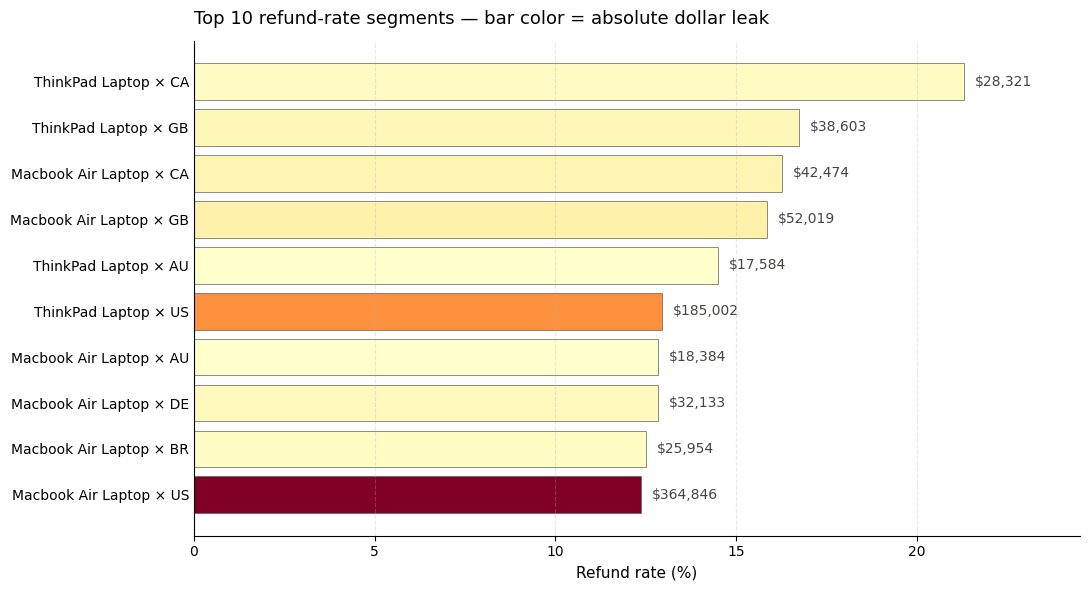


Saved: C:\data-projects\cohort-retention\data\outputs\refund_top_segments.png
File size: 90.0 KB


In [51]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Pull top 10 refund-rate offenders (segments with ≥100 orders for statistical reliability)
refund_top = con.sql("""
SELECT
    product_name || ' × ' || country_code AS segment,
    refund_rate_pct,
    refunded_revenue_usd
FROM mart_refund_metrics
WHERE orders >= 100
ORDER BY refund_rate_pct DESC
LIMIT 10
""").df()

# Sort ascending so highest bar appears at top of chart
refund_top = refund_top.sort_values('refund_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

# Color bars by absolute revenue leak (darker = more $ leaked)
norm = mcolors.Normalize(vmin=refund_top['refunded_revenue_usd'].min(),
                         vmax=refund_top['refunded_revenue_usd'].max())
colors = plt.cm.YlOrRd(norm(refund_top['refunded_revenue_usd']))

bars = ax.barh(refund_top['segment'], refund_top['refund_rate_pct'],
               color=colors, edgecolor='#5F5E5A', linewidth=0.5)

# Annotate each bar with the absolute dollar leak
for i, (rate, dollars) in enumerate(zip(refund_top['refund_rate_pct'],
                                         refund_top['refunded_revenue_usd'])):
    ax.text(rate + 0.3, i, f'${dollars:,.0f}',
            va='center', fontsize=10, color='#444441')

ax.set_xlabel('Refund rate (%)', fontsize=11)
ax.set_title('Top 10 refund-rate segments — bar color = absolute dollar leak',
             loc='left', pad=12, fontsize=13)
ax.set_xlim(0, refund_top['refund_rate_pct'].max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
output_path = PROJECT_ROOT / "data" / "outputs" / "refund_top_segments.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

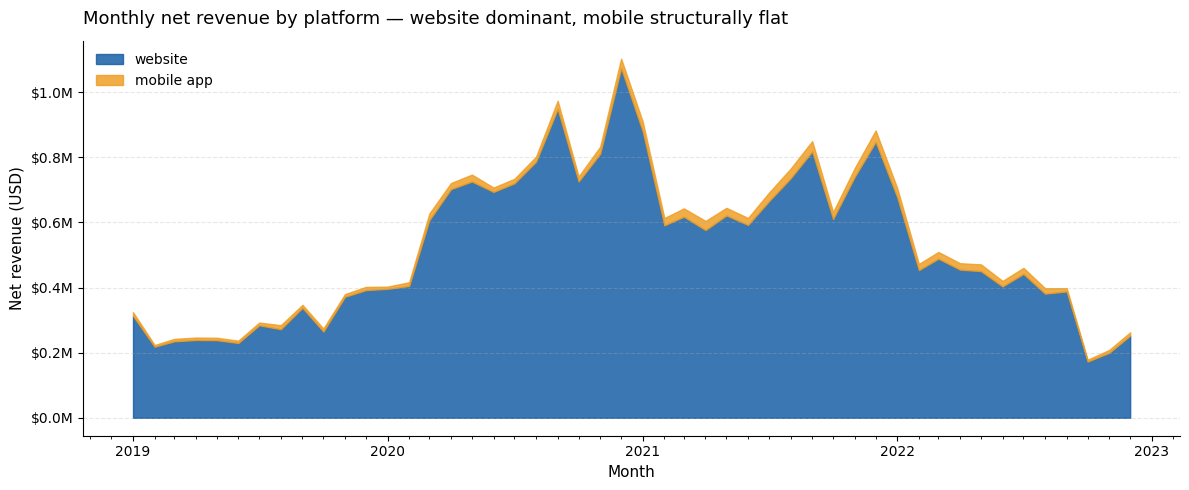


Saved: C:\data-projects\cohort-retention\data\outputs\channel_revenue_trend.png
File size: 101.9 KB


In [52]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pull from the persisted mart
channel_df = con.sql("""
SELECT
    purchase_month,
    purchase_platform,
    net_revenue_usd
FROM mart_channel_revenue
ORDER BY purchase_month, purchase_platform
""").df()

# Pivot to wide format: rows=months, columns=platforms
channel_pivot = channel_df.pivot(
    index='purchase_month',
    columns='purchase_platform',
    values='net_revenue_usd'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))

# Stacked area — website on bottom (dominant), mobile on top
ax.fill_between(channel_pivot.index, 0, channel_pivot['website'],
                color='#185FA5', alpha=0.85, label='website')
ax.fill_between(channel_pivot.index,
                channel_pivot['website'],
                channel_pivot['website'] + channel_pivot['mobile app'],
                color='#EF9F27', alpha=0.85, label='mobile app')

# Format axes
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Net revenue (USD)', fontsize=11)
ax.set_title('Monthly net revenue by platform — website dominant, mobile structurally flat',
             loc='left', pad=12, fontsize=13)

# Year-only ticks on x-axis (monthly ticks would be cluttered)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Format y-axis as $millions
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper left', frameon=False)

plt.tight_layout()
output_path = PROJECT_ROOT / "data" / "outputs" / "channel_revenue_trend.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

In [55]:
import sys
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "reportlab"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
print(result.stderr[-300:] if result.stderr else '')

  Using cached reportlab-4.5.0-py3-none-any.whl.metadata (1.7 kB)
Using cached reportlab-4.5.0-py3-none-any.whl (2.0 MB)




In [58]:
from reportlab.lib.pagesizes import LETTER
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib.colors import HexColor
from reportlab.lib.enums import TA_LEFT
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, PageBreak
)

docs_dir = PROJECT_ROOT / "docs"
docs_dir.mkdir(exist_ok=True)
output_pdf = docs_dir / "openbuild_findings_one_pager.pdf"

doc = SimpleDocTemplate(
    str(output_pdf), pagesize=LETTER,
    leftMargin=0.55*inch, rightMargin=0.55*inch,
    topMargin=0.45*inch, bottomMargin=0.45*inch,
)

styles = getSampleStyleSheet()

# --- TIGHTER STYLES (smaller fonts, less leading, less spacing) ---
style_title = ParagraphStyle('Title', parent=styles['Title'],
    fontName='Helvetica-Bold', fontSize=16, leading=19,
    textColor=HexColor('#0F172A'), alignment=TA_LEFT, spaceAfter=2)
style_subtitle = ParagraphStyle('Subtitle', parent=styles['Normal'],
    fontName='Helvetica', fontSize=9, leading=11,
    textColor=HexColor('#475569'), alignment=TA_LEFT, spaceAfter=6)
style_h2 = ParagraphStyle('H2', parent=styles['Heading2'],
    fontName='Helvetica-Bold', fontSize=10.5, leading=13,
    textColor=HexColor('#0F172A'), spaceBefore=6, spaceAfter=2)
style_finding_label = ParagraphStyle('FindingLabel', parent=styles['Normal'],
    fontName='Helvetica-Bold', fontSize=8, leading=10,
    textColor=HexColor('#475569'), spaceBefore=2, spaceAfter=0)
style_body = ParagraphStyle('Body', parent=styles['Normal'],
    fontName='Helvetica', fontSize=9, leading=11,
    textColor=HexColor('#1F2937'), alignment=TA_LEFT, spaceAfter=2)
style_meta = ParagraphStyle('Meta', parent=styles['Normal'],
    fontName='Helvetica-Oblique', fontSize=7.5, leading=9,
    textColor=HexColor('#64748B'))
style_appendix_h1 = ParagraphStyle('AppendixH1', parent=styles['Heading1'],
    fontName='Helvetica-Bold', fontSize=13, leading=16,
    textColor=HexColor('#0F172A'), spaceAfter=2)
style_appendix_h2 = ParagraphStyle('AppendixH2', parent=styles['Heading2'],
    fontName='Helvetica-Bold', fontSize=10, leading=12,
    textColor=HexColor('#0F172A'), spaceBefore=6, spaceAfter=2)
style_code = ParagraphStyle('Code', parent=styles['Normal'],
    fontName='Courier', fontSize=7.5, leading=9.5,
    textColor=HexColor('#1F2937'), backColor=HexColor('#F1F5F9'),
    borderPadding=3, leftIndent=3, rightIndent=3, spaceAfter=2)
style_appendix_body = ParagraphStyle('AppendixBody', parent=styles['Normal'],
    fontName='Helvetica', fontSize=8.5, leading=10.5,
    textColor=HexColor('#374151'), alignment=TA_LEFT, spaceAfter=2)

def hrule(color='#CBD5E1'):
    t = Table([['']], colWidths=[7.4*inch], rowHeights=[0.5])
    t.setStyle(TableStyle([('LINEABOVE', (0,0), (-1,-1), 0.5, HexColor(color))]))
    return t

def cause_table(rows):
    t = Table(rows, colWidths=[4.8*inch, 0.85*inch, 1.75*inch])
    t.setStyle(TableStyle([
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('FONTSIZE', (0,0), (-1,-1), 8),
        ('TEXTCOLOR', (0,0), (-1,0), HexColor('#475569')),
        ('TEXTCOLOR', (0,1), (-1,-1), HexColor('#1F2937')),
        ('LINEBELOW', (0,0), (-1,0), 0.5, HexColor('#CBD5E1')),
        ('BOTTOMPADDING', (0,0), (-1,-1), 2),
        ('TOPPADDING', (0,0), (-1,-1), 2),
        ('VALIGN', (0,0), (-1,-1), 'TOP'),
    ]))
    return t

# ===== PAGE 1: EXECUTIVE 1-PAGER =====

story = []
story.append(Paragraph("OpenBuild — Executive Findings", style_title))
story.append(Paragraph(
    "Analytics engineering portfolio · 108K orders · 87K users · 2019–2022 · "
    "Medallion architecture · 28 tested transformations",
    style_subtitle))
story.append(hrule('#1F2937'))

# Finding 1
story.append(Paragraph("1. Retention is structurally flat, not strategically broken", style_h2))
story.append(Paragraph("RESULT", style_finding_label))
story.append(Paragraph("~1% month-1 retention across all 48 cohorts (Jan 2019 – Dec 2022). "
    "Acquisition strategy did not move repurchase behavior in any cohort.", style_body))
story.append(Paragraph("IMPLICATION", style_finding_label))
story.append(Paragraph("Marketing initiatives aimed at retention will not move the needle. "
    "The lever is product mix.", style_body))
story.append(Paragraph("CAUSES", style_finding_label))
story.append(cause_table([
    ['Cause', 'Weight', 'Status'],
    ['Durable goods naturally have low repurchase frequency', 'High', 'Tested'],
    ['Catalog skews toward one-time purchases vs. replenishables', 'High', 'Tested'],
    ['Limited cross-sell mechanics in checkout', 'Medium', 'Hypothesis'],
]))
story.append(Paragraph("Source models: mart_cohort_retention, dim_users, fct_orders · See Appendix A1", style_meta))

# Finding 2
story.append(Paragraph("2. Laptops drive 2–3× the company refund rate", style_h2))
story.append(Paragraph("RESULT", style_finding_label))
story.append(Paragraph("Refund baseline: 4.97%. Top offenders are all laptops: ThinkPad × CA (21.3%), "
    "ThinkPad × GB (16.8%), MacBook Air × CA (16.3%). "
    "MacBook Air × US is the largest dollar leak: $365K refunded.", style_body))
story.append(Paragraph("IMPLICATION", style_finding_label))
story.append(Paragraph("Refund-reduction initiatives should target laptops first. "
    "Geographic variation suggests fulfillment or returns-policy investigation by country.", style_body))
story.append(Paragraph("CAUSES", style_finding_label))
story.append(cause_table([
    ['Cause', 'Weight', 'Status'],
    ['High-AOV products carry higher absolute return risk', 'High', 'Tested'],
    ['Spec / expectation mismatch in laptops vs. accessories', 'High', 'Partially tested'],
    ['Country-level returns policy or fulfillment variance', 'Medium', 'Partially tested'],
    ['Localization issues (pricing, positioning)', 'Medium', 'Hypothesis'],
]))
story.append(Paragraph("Source models: mart_refund_metrics, fct_orders, dim_country · See Appendix A2", style_meta))

# Finding 3
story.append(Paragraph("3. Mobile is structurally a low-AOV channel", style_h2))
story.append(Paragraph("RESULT", style_finding_label))
story.append(Paragraph("Website = 96.8% of lifetime revenue. Mobile generates 17% of orders but only 3% of revenue. "
    "Mobile share moved from 2.95% (2019) to 3.93% (2022) — statistically real, business-trivially small.", style_body))
story.append(Paragraph("IMPLICATION", style_finding_label))
story.append(Paragraph("Mobile investment thesis must target AOV, not order volume. "
    "Doubling mobile order volume only adds ~3 percentage points to total revenue at current AOV.", style_body))
story.append(Paragraph("CAUSES", style_finding_label))
story.append(cause_table([
    ['Cause', 'Weight', 'Status'],
    ['Mobile users skew toward accessory purchases', 'High', 'Tested'],
    ['Catalog product mix is desktop-shaped (laptops, monitors)', 'High', 'Tested'],
    ['Mobile UX friction at high-value checkout', 'Medium', 'Hypothesis'],
    ['Desktop preference for large / considered purchases', 'Low–Medium', 'Hypothesis'],
]))
story.append(Paragraph("Source models: mart_channel_revenue, fct_orders, dim_platform · See Appendix A3", style_meta))

story.append(Spacer(1, 4))
story.append(hrule('#CBD5E1'))
story.append(Paragraph("Full analysis, SQL, and tests: github.com/joyce92200/ecommerce-analytics-engineering", style_meta))

# ===== PAGE 2: APPENDIX (compact) =====

story.append(PageBreak())
story.append(Paragraph("Appendix — Methodology", style_appendix_h1))
story.append(Paragraph("Each finding's metric definition, SQL logic, and caveats. "
    "All numbers reproducible from the repository above.", style_meta))
story.append(hrule('#1F2937'))

# A1
story.append(Paragraph("A1 — Cohort retention", style_appendix_h2))
story.append(Paragraph(
    "<b>Metric.</b> Period-active retention: % of a cohort placing at least one order during month N "
    "after acquisition. Not &quot;made a 2nd purchase ever&quot; (different metric).",
    style_appendix_body))
story.append(Paragraph(
    "<b>Cohort definition.</b> cohort_month = DATE_TRUNC('month', MIN(purchase_ts)) per user.",
    style_appendix_body))
story.append(Paragraph(
    "retention_pct = active_users / cohort_size × 100<br/>"
    "active_users = COUNT(DISTINCT user_id) per (cohort_month, months_since_acquisition)<br/>"
    "cohort_size = active_users at months_since_acquisition = 0",
    style_code))
story.append(Paragraph(
    "<b>Caveats.</b> Cohorts after Dec 2021 are right-censored — month-12 retention is unobservable "
    "given the data window ending Dec 2022. Matrix reported only for fully observable cells. "
    "3 orders (0.003%) with unparseable purchase timestamps excluded.",
    style_appendix_body))

# A2
story.append(Paragraph("A2 — Refund metrics", style_appendix_h2))
story.append(Paragraph(
    "<b>Metric.</b> Two metrics at (product × country) grain: <i>refund_rate_pct</i> = refunded orders / total × 100; "
    "<i>refunded_revenue_usd</i> = SUM(usd_price WHERE is_refunded = 1).",
    style_appendix_body))
story.append(Paragraph(
    "<b>Refund definition.</b> An order is refunded if refund_ts is non-null. "
    "Partial vs. full refunds are not distinguished in the source.",
    style_appendix_body))
story.append(Paragraph(
    "WHERE orders &gt;= 100<br/>"
    "ORDER BY refund_rate_pct DESC<br/>"
    "LIMIT 10",
    style_code))
story.append(Paragraph(
    "<b>Caveats.</b> 100-order minimum is a statistical-reliability threshold. "
    "4 orders with NULL country_code retained as a distinct segment so unknown-geo leakage stays visible. "
    "18 orders with non-standard codes (EU, AP) mapped to Unclassified for referential integrity.",
    style_appendix_body))

# A3
story.append(Paragraph("A3 — Channel revenue", style_appendix_h2))
story.append(Paragraph(
    "<b>Metric.</b> Net revenue (gross minus refunded) by (purchase_month × purchase_platform) "
    "with within-month share %.",
    style_appendix_body))
story.append(Paragraph(
    "net_revenue_usd = SUM(usd_price WHERE is_refunded = 0)<br/>"
    "share_of_month_pct = net_revenue / SUM(net_revenue) OVER (PARTITION BY purchase_month) × 100",
    style_code))
story.append(Paragraph(
    "<b>Trend comparison.</b> 2019 vs. 2022 share = aggregate all months in each year, "
    "then take the platform's share within that year.",
    style_appendix_body))
story.append(Paragraph(
    "<b>Caveats.</b> Channel attribution is platform-only (website vs. mobile app). "
    "Marketing channel attribution is unavailable (upstream column &gt;99% null). "
    "AOV comparisons use net_revenue / orders across platforms.",
    style_appendix_body))

story.append(Spacer(1, 4))
story.append(hrule('#CBD5E1'))
story.append(Paragraph("How to verify", style_appendix_h2))
story.append(Paragraph(
    "Clone the repository, install requirements, open notebooks/01_cohort_exploration.ipynb, "
    "and run all cells top-to-bottom. Each finding corresponds to a specific cell whose output "
    "matches the numbers reported. The 28 data quality tests in tests/test_models.sql validate every input model.",
    style_appendix_body))

doc.build(story)

print(f"Saved: {output_pdf}")
print(f"File size: {output_pdf.stat().st_size / 1024:.1f} KB")

Saved: C:\data-projects\cohort-retention\docs\openbuild_findings_one_pager.pdf
File size: 6.6 KB
